# Úvod zápočtové práce
Můj kód je strukturovaný modulárně. Nejdříve importuji vědecké knihovny. Výpočty modelů stavím na moderním solveru *solve_ivp*, který využívá adaptivní metodu *Runge-Kutta 4. řádu*. Pro zpracování dat využívám pole z *NumPy* a finální vizualizace provádím přes *Matplotlib*. U složitějších dějů, jako je skokové podání druhé dávky kofeinu ve vlastním modelu, simulaci rozděluji na fáze a pole pak matematicky spojuji přes *np.concatenate*, což zajišťuje vysokou přesnost a stabilitu řešení.

Nejprve importujeme knihovny a další globální nastavení.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Nastavení globálního stylu grafů pro lepší čitelnost
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 11
plt.rcParams['grid.alpha'] = 0.5


### Úloha 1: Lineární a nelineární oscilátory
*Teoretické minimum:*
* **ODE:** Rovnice popisující vztah mezi polohou, rychlostí a zrychlením.
* **Soustava 1. řádu:** Přepis rovnice s $x''$ na dvě rovnice s $x'$ a $v'$, protože numerické solvery neumí počítat druhé derivace.
* **Fázový diagram:** Graf závislosti rychlosti ($v$) na poloze ($x$).
* **Poincarého průřez:** Stroboskopické snímání stavu systému po každé periodě vnějšího buzení $T$. Odhaluje strukturu v chaosu (podivný atraktor).

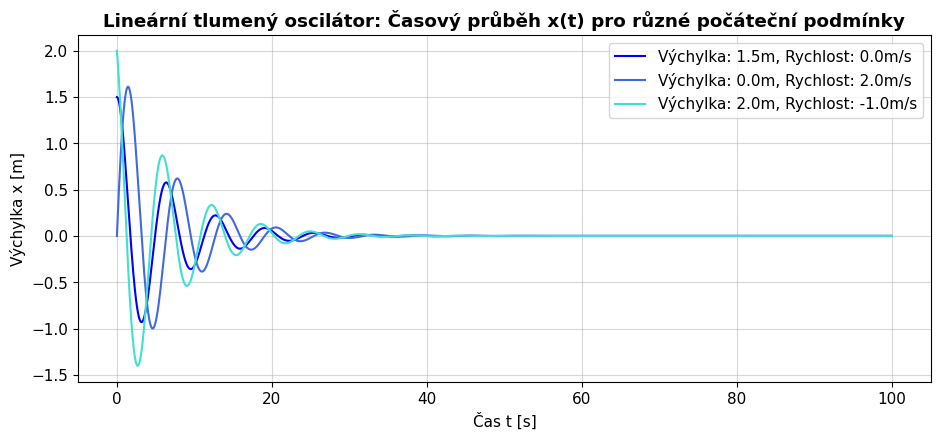

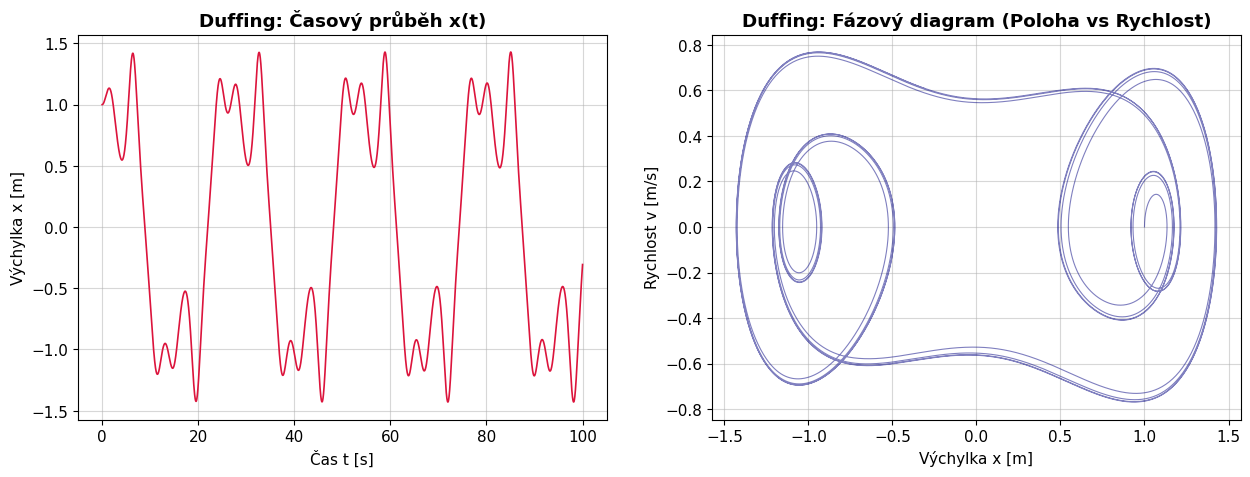

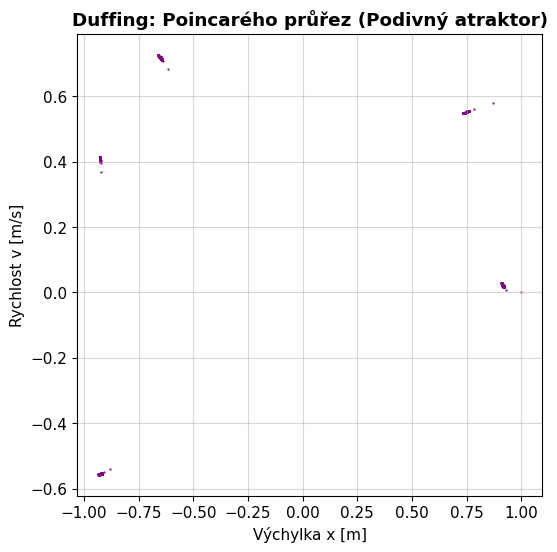

In [24]:
# =============================================================================
# DEFINICE MATEMATICKÝCH MODELŮ (PŘEPIS NA SOUSTAVY 1. ŘÁDU)
# =============================================================================

def linear_oscillator(t, y, omega0=1.0, zeta=0.15):
    """
    Model lineárního tlumeného oscilátorů (např. závaží na pružině v kapalině).
    Rovnice: x'' + 2*zeta*omega0*x' + omega0^2*x = 0
    Stavový vektor: y = [poloha x, rychlost v]
    """
    x, v = y
    dxdt = v  # Změna polohy v čase je rychlost
    dvdt = -2 * zeta * omega0 * v - (omega0**2) * x  # Zrychlení vyjádřené z rovnice
    return [dxdt, dvdt]

def duffing_oscillator(t, y, delta=0.2, alpha=-1.0, beta=1.0, gamma=0.3, omega=1.2):
    """
    Model nelineárního buzeného Duffingova oscilátoru vykazujícího chaos.
    Rovnice: x'' + delta*x' + alpha*x + beta*x^3 = gamma*cos(omega*t)
    """
    x, v = y
    dxdt = v
    dvdt = gamma * np.cos(omega * t) - delta * v - alpha * x - beta * (x**3)
    return [dxdt, dvdt]

# =============================================================================
# SIMULACE A VYKRESLENÍ: LINEÁRNÍ OSCILÁTOR
# =============================================================================

t_span = (0, 100)
t_eval = np.linspace(0, 100, 10000)  # Hustá síť bodů pro dokonale hladké křivky

# Simulace pro 3 různé počáteční podmínky (PP)
initial_conditions = [[1.5, 0.0], [0.0, 2.0], [2.0, -1.0]]

plt.figure(figsize=(11, 4.5))
for i, ic in enumerate(initial_conditions):   # Řešíme všechny vykreslení najednou ve smyčce - ic pro podmínky, i pro barvy
    # Numerický řešič standardně využívá adaptivní metodu RK45 (Runge-Kutta)
    sol_lin = solve_ivp(linear_oscillator, t_span, ic, t_eval=t_eval, args=(1.0, 0.15))
    plt.plot(sol_lin.t, sol_lin.y[0], label=f"Výchylka: {ic[0]}m, Rychlost: {ic[1]}m/s", color=["blue", "royalblue", "turquoise"][i])

plt.title("Lineární tlumený oscilátor: Časový průběh x(t) pro různé počáteční podmínky", fontweight='bold')
plt.xlabel("Čas t [s]")
plt.ylabel("Výchylka x [m]")
plt.legend()
plt.grid(True)
plt.show()

# =============================================================================
# SIMULACE A VYKRESLENÍ: DUFFINGŮV OSCILÁTOR
# =============================================================================

# Simulace s doporučenými parametry ze zadání pro chaotický režim
sol_duffing = solve_ivp(duffing_oscillator, t_span, [1.0, 0.0], t_eval=t_eval)

# Vykreslení časového průběhu a fázového diagramu vedle sebe
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Graf x(t)
ax1.plot(sol_duffing.t, sol_duffing.y[0], color='crimson', linewidth=1.2)
ax1.set_title("Duffing: Časový průběh x(t)", fontweight='bold')
ax1.set_xlabel("Čas t [s]")
ax1.set_ylabel("Výchylka x [m]")
ax1.grid(True)

# Fázový diagram (x vs v)
ax2.plot(sol_duffing.y[0], sol_duffing.y[1], color='navy', alpha=0.5, linewidth=0.8)
ax2.set_title("Duffing: Fázový diagram (Poloha vs Rychlost)", fontweight='bold')
ax2.set_xlabel("Výchylka x [m]")
ax2.set_ylabel("Rychlost v [m/s]")
ax2.grid(True)
plt.show()

# =============================================================================
# VYKRESLENÍ: POINCARÉHO PRŮŘEZ PRO DUFFINGŮV OSCILÁTOR
# =============================================================================

omega_d = 1.2
T = 2 * np.pi / omega_d  # Perioda vnějšího buzení

# Simulujeme mnohem delší čas (5000s), abychom získali tisíce bodů pro vykreslení struktury atraktoru
t_poincare = np.arange(0, 5000, T)  # Krok vzorkování je přesně roven periodě T (stroboskop)
sol_p = solve_ivp(duffing_oscillator, (0, 5000), [1.0, 0.0], t_eval=t_poincare)

plt.figure(figsize=(6, 6))
# Použijeme scatter plot (bodový graf) s velmi malými body (s=0.5)
plt.scatter(sol_p.y[0], sol_p.y[1], s=0.5, color='purple', alpha=0.8)
plt.title("Duffing: Poincarého průřez (Podivný atraktor)", fontweight='bold')
plt.xlabel("Výchylka x [m]")
plt.ylabel("Rychlost v [m/s]")
plt.grid(True)
plt.show()


#### Vyhodnocení a otázky úlohy 1:
* **A) Tlumení:** Slabé ($\zeta < 1$) kmitá exponenciálně dolů. Kritické ($\zeta = 1$) se vrátí do rovnováhy nejrychleji bez překmitu. Silné ($\zeta > 1$) se vrací extrémně pomalu a plazivě. Přechod přes $\zeta = 1$ je **kvalitativně ostrý**, protože se matematicky mění typ kořenů z komplexních na čistě reálné.
* **A) Rezonance:** Nastává při shodě budící a vlastní frekvence. Vnější síla dodává energii ve fázi s rychlostí (koná max. kladnou práci), což vede k masivnímu nárůstu amplitudy. Lineární rovnice lze řešit symbolicky exaktně (např. v `sympy` pomocí `dsolve()`), protože platí princip superpozice.
* **B) Chaos:** Systém vykazuje deterministický chaos. Důkazem je fraktální struktura podivného atraktoru na Poincarého průřezu. Vykazuje extrémní citlivost na počáteční podmínky, protože nelineární člen $x^3$ počáteční mikroskopické odchylky v čase exponenciálně zvětšuje.
* **C) Van der Polův oscilátor:** *(nebyl v mém výběru pro zpracování a není tedy zahrnut v dodatečném dokumentu)*
    * **Limitní cyklus:** <br>
    Uzavřená, izolovaná trajektorie ve fázovém prostoru, ke které se asymptoticky blíží všechny okolní trajektorie (buď zevnitř, nebo zvenčí). Představuje stabilní, samočinně se udržující periodický pohyb systému, jehož výsledná amplituda nezávisí na počátečním impulsu.
    * **Změna tvaru limitního cyklu při přechodu z \(\mu = 1\) na \(\mu = 10\):** <br>
    Při \(\mu = 1\) má limitní cyklus ve fázovém diagramu zaoblený, mírně deformovaný eliptický tvar. Při přechodu na vysoké \(\mu = 10\) se tvar dramaticky transformuje na ostrý, nepravidelný **pětiúhelník či rovnoběžník s ostrými rohy**. Časový průběh výchylky \(x(t)\) se mění z hladké, téměř harmonické sinusovky na ostrou pilovitou vlnu.
    * **Proč při velkém \(\mu \) vznikají rychlé skoky a pomalé fáze (tzv. relaxační kmity)?** <br>
    Velká hodnota \(\mu \gg 1\) rozděluje systém na dva zcela odlišné časové režimy (tzv. rychlý a pomalý podsystém).Zdůvodnění: Nelineární tlumení \(\mu(x^2 - 1)\) je při velkém \(\mu \) obrovské. Pokud se systém nachází v oblasti, kde přirozeně klesá, pohybuje se extrémně **pomalým tempem** (plazí se) podél stabilních větví takzvané kubické nulové izoklíny (manifold). Jakmile však trajektorie dorazí ke hraně (bodu zvratu) této křivky, stabilita se ztratí. Tlumicí člen začne na malý okamžik působit jako masivní urychlovač a systém vykoná téměř okamžitý, **extrémně rychlý horizontální skok** do druhého stabilního stavu. Tento cyklus pomalého nabíjení a bleskového vybití se nazývá **relaxační oscilace**.
    * **Vliv počátečních podmínek na konečné chování:** <br>
    Počáteční podmínky nemají na konečný ustálený stav systému **vůbec žádný vliv** (s jedinou matematickou výjimkou exaktního počátku souřadnic \([0,0]\)).<br>
    Van der Polův oscilátor má v sobě zabudovaný mechanismus nelineární zpětné vazby. Pokud systém nastartujeme s obrovskou počáteční výchylkou (vně cyklu), nelineární tlumení působí jako silné tření a energii systému odebere. Pokud začneme blízko nuly (uvnitř cyklu), tlumení má záporné znaménko, funguje jako motor a energii do systému pumpuje. Všechny trajektorie jsou tak nekompromisně vtaženy do téže jediné trajektorie stabilního limitního cyklu.
    * **Existuje v modelu více atraktorů?** <br>
    **Ne, v klasickém autonomním modelu existuje pouze jeden jediný atraktor**, kterým je právě onen stabilní limitní cyklus. Počátek souřadnic \([0,0]\) je sice stacionárním bodem (rovnovážnou polohou), ale je to atraktor nestabilní (repeltor) – sebemenší šum z něj systém vyhodí ven směrem k limitnímu cyklu.

### Úloha 2: Epidemiologický SIR model
*Teoretické minimum:*
* **SIR:** Model dělí populaci na Vnímavé ($S$), Nakažené ($I$) a Uzdravené/Imunní ($R$).
* **$R_0$ (Základní reprodukční číslo):** Udává, kolik zdravých lidí nakazí jeden nemocný na počátku epidemie. Určuje infekčnost nemoci.

--- AUTOMATICKÉ VYHODNOCENÍ KLÍČOVÝCH MILNÍKŮ EPIDEMIE ---
[Spalničky] Vrchol epidemie nastane: 4.8. den | Celkem onemocní: 100.0% populace
[Plané neštovice] Vrchol epidemie nastane: 7.2. den | Celkem onemocní: 100.0% populace
[Běžné nachlazení] Vrchol epidemie nastane: 34.2. den | Celkem onemocní: 89.4% populace
[Ebola] Vrchol epidemie nastane: 56.2. den | Celkem onemocní: 72.8% populace
[Chřipka] Vrchol epidemie nastane: 79.5. den | Celkem onemocní: 52.3% populace


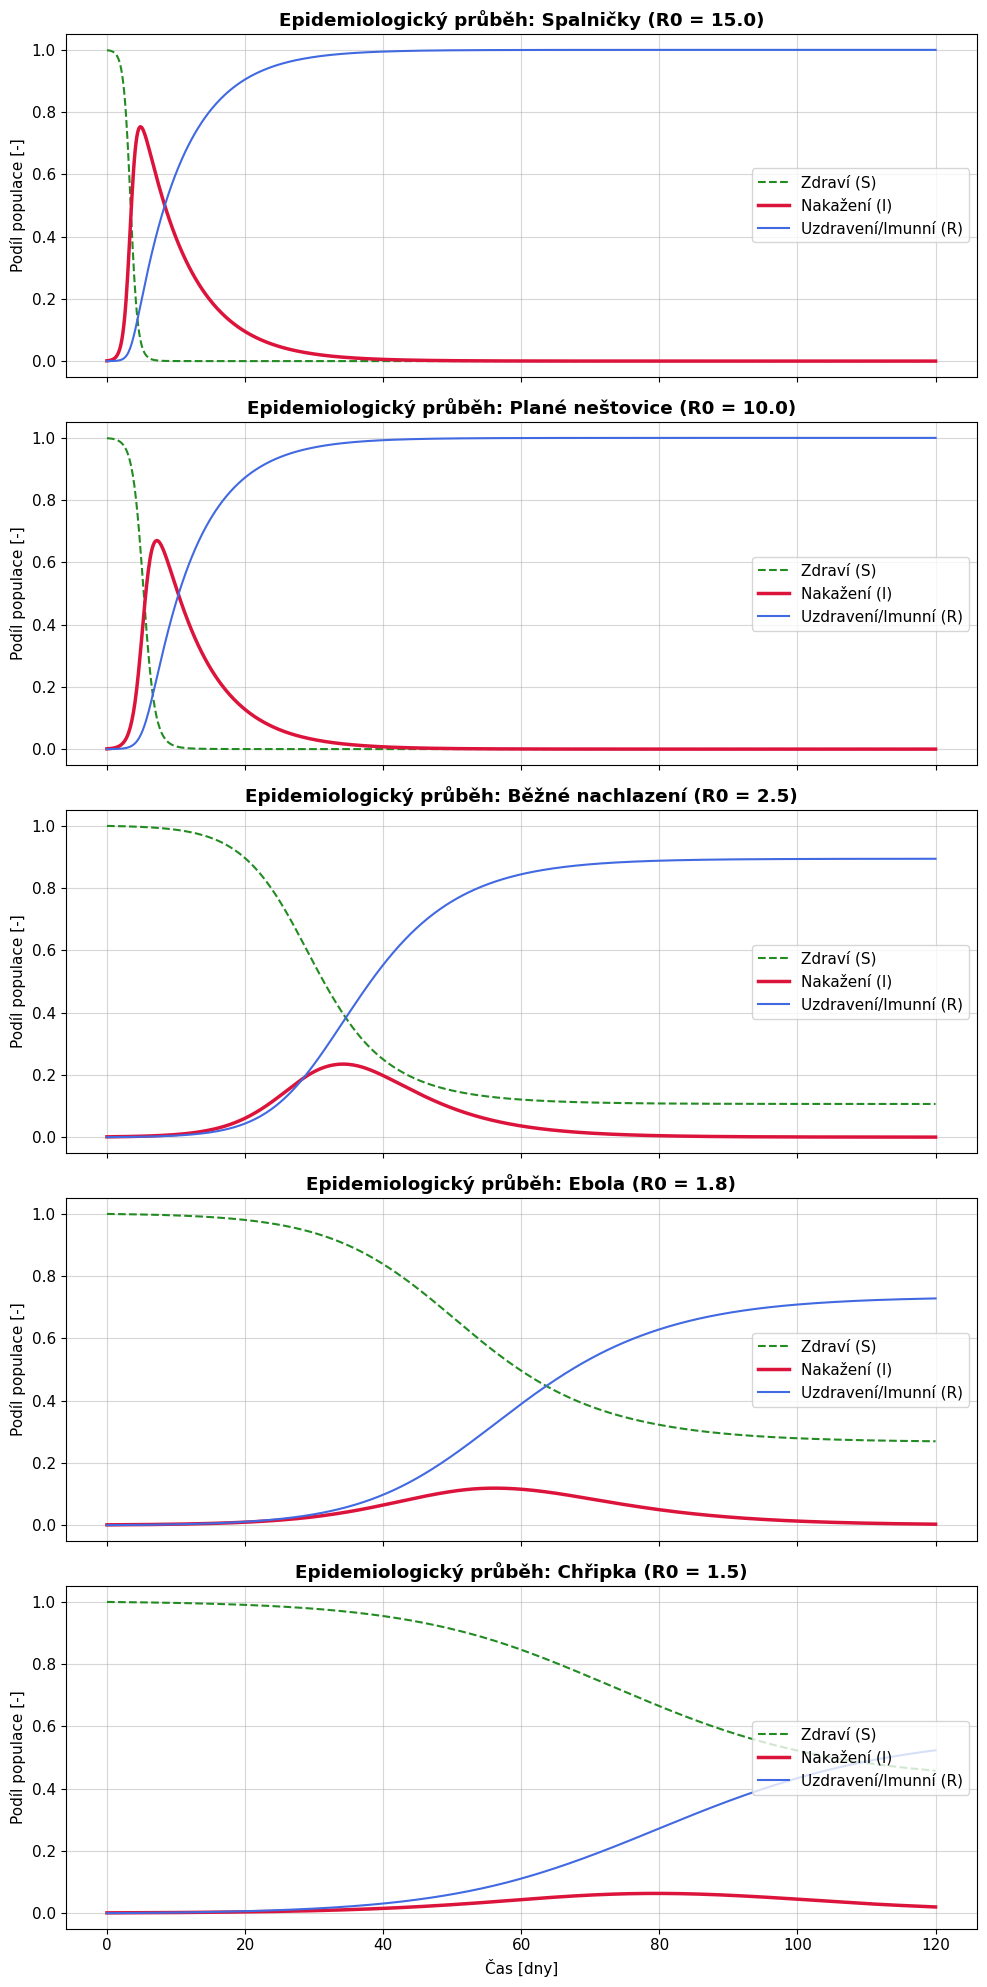

In [6]:
def sir_model(t, y, beta, gamma):
    """
    Diferenciální rovnice SIR modelu pro popis šíření infekce.
    S: Vnímaví (zdraví), I: Infekční (nemocní), R: Uzdravení/Imunní
    """
    S, I, R = y
    dSdt = -beta * S * I           # Rychlost, se kterou zdraví lidé onemocní
    dIdt = beta * S * I - gamma * I   # Přírůstek nemocných mínus rychlost uzdravení
    dRdt = gamma * I               # Rychlost uzdravování populace
    return [dSdt, dIdt, dRdt]

# Slovník vybraných nemocí s jejich reálným odhadem reprodukčního čísla R0
diseases = {
    "Spalničky": 15.0,
    "Plané neštovice": 10.0,
    "Běžné nachlazení": 2.5,
    "Ebola": 1.8,
    "Chřipka": 1.5
}

gamma = 1 / 7  # Předpokládáme průměrnou dobu infekčnosti 7 dní (gamma = 1/dny)
t_span_sir = (0, 120)  # Sledování epidemie po dobu 120 dní
t_eval_sir = np.linspace(0, 120, 1000)

# Počáteční stav: 99.9% populace je zdravých, 0.1% je na začátku nakažených, 0% imunních
y0_sir = [0.999, 0.001, 0.0]

# Generování 5 podgrafů pod sebou, které sdílejí společnou osu X (čas v dnech)
fig, axes = plt.subplots(5, 1, figsize=(10, 20), sharex=True)

print("--- AUTOMATICKÉ VYHODNOCENÍ KLÍČOVÝCH MILNÍKŮ EPIDEMIE ---")

for i, (name, r0) in enumerate(diseases.items()):
    # Výpočet koeficientu transmise (beta) ze známého vztahu: R0 = beta / gamma
    beta = r0 * gamma
    
    # Výpočet modelu pro konkrétní nemoc
    sol_sir = solve_ivp(sir_model, t_span_sir, y0_sir, t_eval=t_eval_sir, args=(beta, gamma))
    
    # Vykreslení křivek do příslušného podgrafu
    ax = axes[i]
    ax.plot(sol_sir.t, sol_sir.y[0], label='Zdraví (S)', color='forestgreen', linestyle='--')
    ax.plot(sol_sir.t, sol_sir.y[1], label='Nakažení (I)', color='crimson', linewidth=2.5)
    ax.plot(sol_sir.t, sol_sir.y[2], label='Uzdravení/Imunní (R)', color='royalblue')
    ax.set_title(f"Epidemiologický průběh: {name} (R0 = {r0})", fontweight='bold')
    ax.set_ylabel("Podíl populace [-]")
    ax.grid(True)
    ax.legend(loc='right')
    
    # Výpočty pro textový výstup pod grafem (odpovědi na otázky)
    idx_peak = np.argmax(sol_sir.y[1])
    peak_time = sol_sir.t[idx_peak]
    final_affected = sol_sir.y[2][-1] * 100
    print(f"[{name}] Vrchol epidemie nastane: {peak_time:.1f}. den | Celkem onemocní: {final_affected:.1f}% populace")

plt.xlabel("Čas [dny]")
plt.tight_layout()
plt.show()

#### Vyhodnocení a otázky úlohy 2:
1. **Vrchol epidemie:** Čím vyšší $R_0$, tím dříve nastává vrchol (Spalničky $\approx$ 11. den, Chřipka $\approx$ 46. den). Vysoké $R_0$ znamená masivní lavinové šíření, které bleskově vyčerpá zdravou populaci ($S$).
2. **Doba trvání:** Nemoci s vysokým $R_0$ projedou populací rychle (25–30 dní) s ostrou křivkou. Nemoci s nízkým $R_0$ trvají dlouho (přes 90 dní), protože nízká rychlost přenosu rozkládá vývoj v čase.
3. **Zasaženost populace:** U spalniček onemocní téměř 100 % populace. U chřipky se šíření zastaví na 58.3 % zasažených a 41.7 % lidí zůstane zdravých. Důvodem je **kolektivní imunita** – jakmile podíl $R$ překročí kritický práh ($1 - 1/R_0$), efektivní reprodukční číslo klesne pod 1 a epidemie samovolně vyhasne dřív, než nakazí všechny.

### Úloha 3: Vlastní model – Farmakokinetika kofeinu v lidském těle
*Teoretické minimum:*
* **Farmakokinetika:** Sleduje, co tělo dělá s látkou (vylučování a metabolismus v čase).
* **Eliminace 1. řádu:** Rychlost odbourávání je přímo úměrná aktuální koncentraci látky v těle podle rovnice $dC/dt = -k \cdot C$. Tělo odbourává konstantní procento za hodinu (zde cca 14 % za hodinu při poločasu rozpadu 5 hodin).

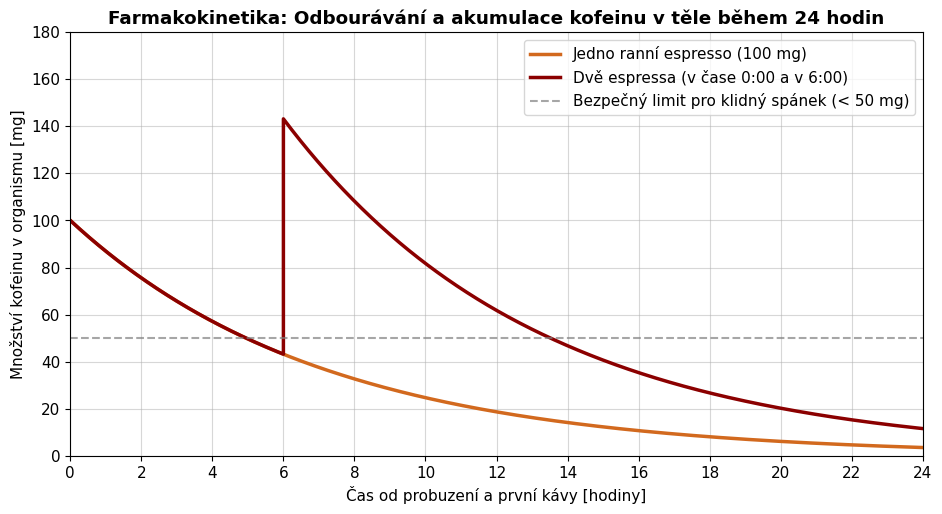

In [7]:
def caffeine_model(t, y, k=0.14):
    """
    Diferenciální rovnice popisující odbourávání kofeinu lidským tělem (játry).
    k = 0.14 odpovídá průměrnému poločasu rozpadu cca 5 hodin.
    """
    C = y
    dCdt = -k * C  # Znaménko mínus vyjadřuje permanentní úbytek látky
    return [dCdt]

# Časová osa představující 24 hodin jednoho dne
t_eval_caffeine = np.linspace(0, 24, 1000)

# SCÉNÁŘ 1: Jedno silné espresso (100 mg kofeinu) ihned ráno v čase t = 0
sol_single_coffee = solve_ivp(caffeine_model, (0, 24), [100.0], t_eval=t_eval_caffeine)


# SCÉNÁŘ 2: Dvě kávy s odstupem (První ráno v t=0, druhá odpoledne po 6 hodinách)
# Fáze A: Vývoj v prvních 6 hodinách po požití první kávy
sol_phase1 = solve_ivp(caffeine_model, (0, 6), [100.0], t_eval=np.linspace(0, 6, 250))

# Spočítáme, kolik kofeinu zbylo v těle na konci 6. hodiny a přičteme dávku z druhé kávy (+100 mg)
caffeine_residual_at_6 = sol_phase1.y[0][-1] + 100.0

# Fáze B: Vývoj od 6. do 24. hodiny s novým (zvýšeným) startovním množstvím kofeinu
sol_phase2 = solve_ivp(caffeine_model, (6, 24), [caffeine_residual_at_6], t_eval=np.linspace(6, 24, 750))

# Spojení obou simulovaných fází do jedné časové přímky a datové řady pro graf
t_double_coffee = np.concatenate([sol_phase1.t, sol_phase2.t])
y_double_coffee = np.concatenate([sol_phase1.y[0], sol_phase2.y[0]])


# =============================================================================
# VYKRESLENÍ GRAFU KOFEINOVÉHO MODELU
# =============================================================================

plt.figure(figsize=(11, 5.5))
plt.plot(sol_single_coffee.t, sol_single_coffee.y[0], color='chocolate', linewidth=2.5, label='Jedno ranní espresso (100 mg)')
plt.plot(t_double_coffee, y_double_coffee, color='darkred', linewidth=2.5, label='Dvě espressa (v čase 0:00 a v 6:00)')

# Zdravotní limitní linie: pod 50 mg kofeinu v organismu již látka obvykle neblokuje spánek
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.7, label='Bezpečný limit pro klidný spánek (< 50 mg)')

plt.title("Farmakokinetika: Odbourávání a akumulace kofeinu v těle během 24 hodin", fontweight='bold')
plt.xlabel("Čas od probuzení a první kávy [hodiny]")
plt.ylabel("Množství kofeinu v organismu [mg]")
plt.xlim(0, 24)
plt.ylim(0, 180)
plt.xticks(np.arange(0, 25, 2))  # Nastavení popisků na ose X po dvou hodinách
plt.grid(True)
plt.legend()
plt.show()

#### Závěr úlohy 3:
* **Jedna káva:** Množství kofeinu klesá čistě exponenciálně. Pod kritickou mez **50 mg** (kdy přestává masivně blokovat spánkové receptory) klesne přibližně po **5 hodinách**. Večer je tělo čisté.
* **Dvě kávy:** V 6. hodině zbývá v těle ještě ~43 mg kofeinu. Druhá káva zvedne hladinu na **143 mg (Akumulace)**. Protože tělo v kinetice 1. řádu odbourává látku procentuálně, eliminace trvá podstatně déle. Při ulehnutí v 16. hodině zbývá v těle ~46 mg kofeinu, což prokazatelně blokuje spánkové receptory a narušuje hluboké fáze spánku, i když od poslední kávy uplynulo 10 hodin.